# A04 — Where RouteRec Helps Most: Bins & Behavioral Slices
Covers Appendix C (session/freq bins) and Appendix I (behavioral slice analysis):
- Figure C1: special-bin evaluation (a) session-length, (b) target-frequency
- Figure I1: behavioral slice analysis (a) MRR@20, (b) relative gain + route concentration


In [ ]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import appendix_viz_helpers as viz
importlib.reload(viz)

apply_style    = viz.apply_style
load_csv       = viz.load_csv
annotate_demo  = viz.annotate_demo
clean_axes     = viz.clean_axes
dataset_label  = viz.dataset_label
metric_limits  = viz.metric_limits
palette_for    = viz.palette_for
bar_line_panel = viz.bar_line_panel
panel_label    = viz.panel_label
PALETTE        = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
apply_style()

MODEL_COLORS = {
    'RouteRec':     PALETTE['route'],
    'SASRec':       PALETTE['blue'],
    'BestBaseline': PALETTE['orange'],
}


In [2]:
# appendix_special_bins.csv     cols: dataset, model, bin_type (session|freq), group, test_seen_mrr20
# appendix_behavior_slice_quality.csv  cols: dataset, model, group, test_seen_mrr20, route_concentration
bins_df   = load_csv('appendix_special_bins.csv')
slices_df = load_csv('appendix_behavior_slice_quality.csv')
bins_df['dataset_label']   = bins_df['dataset'].map(dataset_label)
slices_df['dataset_label'] = slices_df['dataset'].map(dataset_label)
COMPARE_MODELS = ['RouteRec', 'SASRec', 'BestBaseline']
print(f"bins: {bins_df.shape}  slices: {slices_df.shape}")
print("bin_type values:", bins_df['bin_type'].unique())
print("slice groups:   ", slices_df['group'].unique())


bins: (72, 8)  slices: (48, 8)
bin_type values: ['session' 'freq']
slice groups:    ['memory_plus' 'focus_plus' 'tempo_plus' 'exploration_plus']


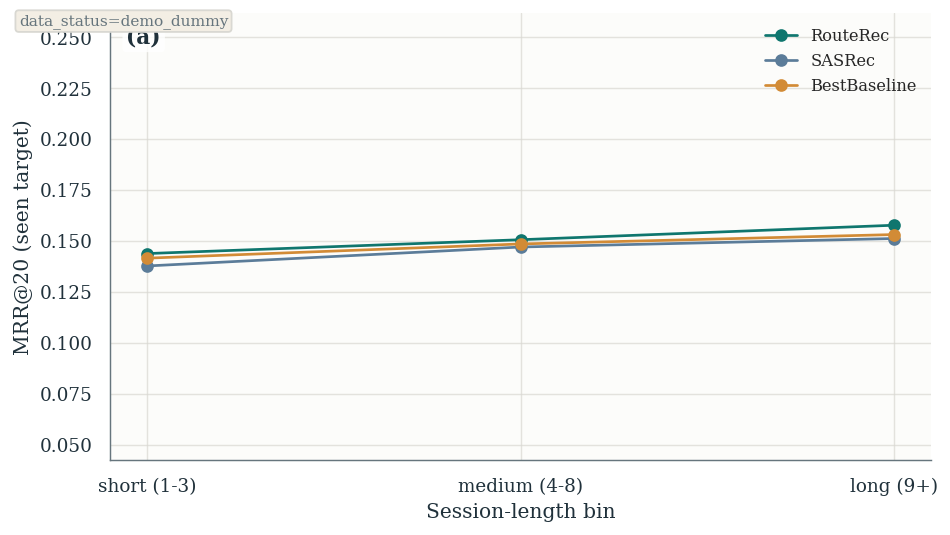

In [ ]:
# ── Figure C1(a) — MRR@20 by session-length bin ────────────────────────────────
SESSION_BIN_ORDER = ['short (1-3)', 'medium (4-8)', 'long (9+)']
sub_sess = bins_df[bins_df['bin_type'] == 'session']

fig, ax = plt.subplots(figsize=(6.4, 3.8), constrained_layout=True)
for mdl in COMPARE_MODELS:
    vals = (
        sub_sess[sub_sess['model'] == mdl]
        .groupby('group', as_index=False)['test_seen_mrr20'].mean()
        .set_index('group').reindex(SESSION_BIN_ORDER)['test_seen_mrr20']
    )
    ax.plot(SESSION_BIN_ORDER, vals.values, marker='o', label=mdl, color=MODEL_COLORS[mdl],
            linewidth=2.1, markersize=5.4)
ax.set_xlabel('Session-length bin')
ax.set_ylabel('MRR@20 (seen target)')
ax.set_ylim(*metric_limits(sub_sess['test_seen_mrr20'], padding=0.22, floor=0.0))
ax.legend(fontsize=9)
clean_axes(ax)
annotate_demo(fig, sub_sess)
plt.show()


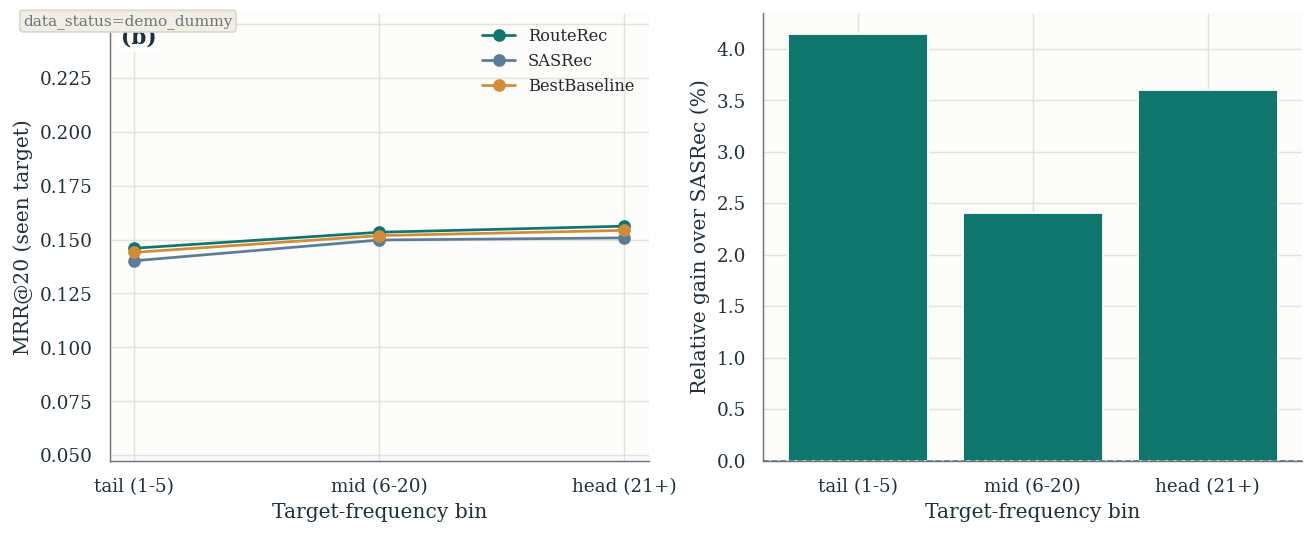

In [ ]:
# ── Figure C1(b) — MRR@20 by target-frequency bin ──────────────────────────────
FREQ_BIN_ORDER = ['tail (1-5)', 'mid (6-20)', 'head (21+)']
sub_freq = bins_df[bins_df['bin_type'] == 'freq']

fig, ax = plt.subplots(figsize=(6.4, 3.8), constrained_layout=True)
for mdl in COMPARE_MODELS:
    vals = (
        sub_freq[sub_freq['model'] == mdl]
        .groupby('group', as_index=False)['test_seen_mrr20'].mean()
        .set_index('group').reindex(FREQ_BIN_ORDER)['test_seen_mrr20']
    )
    ax.plot(FREQ_BIN_ORDER, vals.values, marker='o', label=mdl, color=MODEL_COLORS[mdl],
            linewidth=2.1, markersize=5.4)
ax.set_xlabel('Target-frequency bin')
ax.set_ylabel('MRR@20 (seen target)')
ax.set_ylim(*metric_limits(sub_freq['test_seen_mrr20'], padding=0.22, floor=0.0))
ax.legend(fontsize=9)
clean_axes(ax)
annotate_demo(fig, sub_freq)
plt.show()


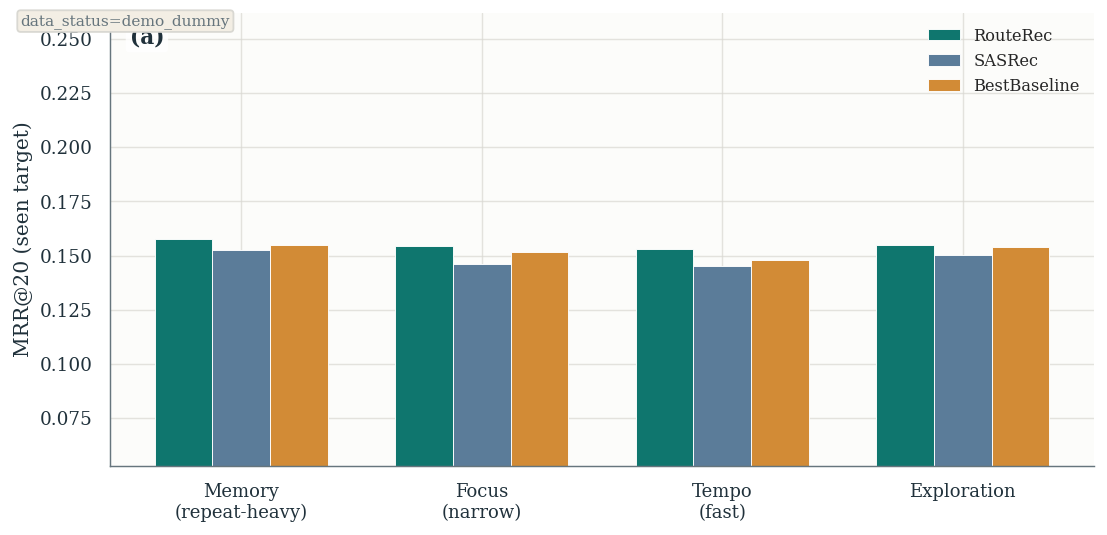

In [ ]:
# ── Figure I1(a) — MRR@20 by behavioral slice per dataset (RouteRec vs baselines) ──
SLICE_ORDER  = ['memory_plus', 'focus_plus', 'tempo_plus', 'exploration_plus']
SLICE_LABELS = {
    'memory_plus':      'Memory',
    'focus_plus':       'Focus',
    'tempo_plus':       'Tempo',
    'exploration_plus': 'Explor.',
}
slices_df['slice_label'] = slices_df['group'].map(SLICE_LABELS).fillna(slices_df['group'])
slice_short_order = [SLICE_LABELS[s] for s in SLICE_ORDER]

datasets_i = [d for d in ['beauty', 'foursquare', 'KuaiRecLargeStrictPosV2_0.2', 'movielens1m']
              if d in slices_df['dataset'].unique()]

# One subplot per dataset; bars = RouteRec MRR@20, line = RouteRec route concentration
fig, axes = plt.subplots(1, len(datasets_i), figsize=(4.0 * len(datasets_i), 3.8),
                          constrained_layout=True)
axes = [axes] if len(datasets_i) == 1 else list(axes)

for ax, ds in zip(axes, datasets_i):
    sub_rr = slices_df[(slices_df['dataset'] == ds) & (slices_df['model'] == 'RouteRec')].copy()
    bar_line_panel(sub_rr, category_col='slice_label',
                   bar_col='test_seen_mrr20', line_col='route_concentration',
                   ax=ax, order=slice_short_order,
                   bar_label='MRR@20 (seen)', line_label='Route conc.',
                   xrotation=0)
    ax.set_title(DATASET_LABELS.get(ds, ds), fontsize=11)

annotate_demo(fig, slices_df)
plt.show()


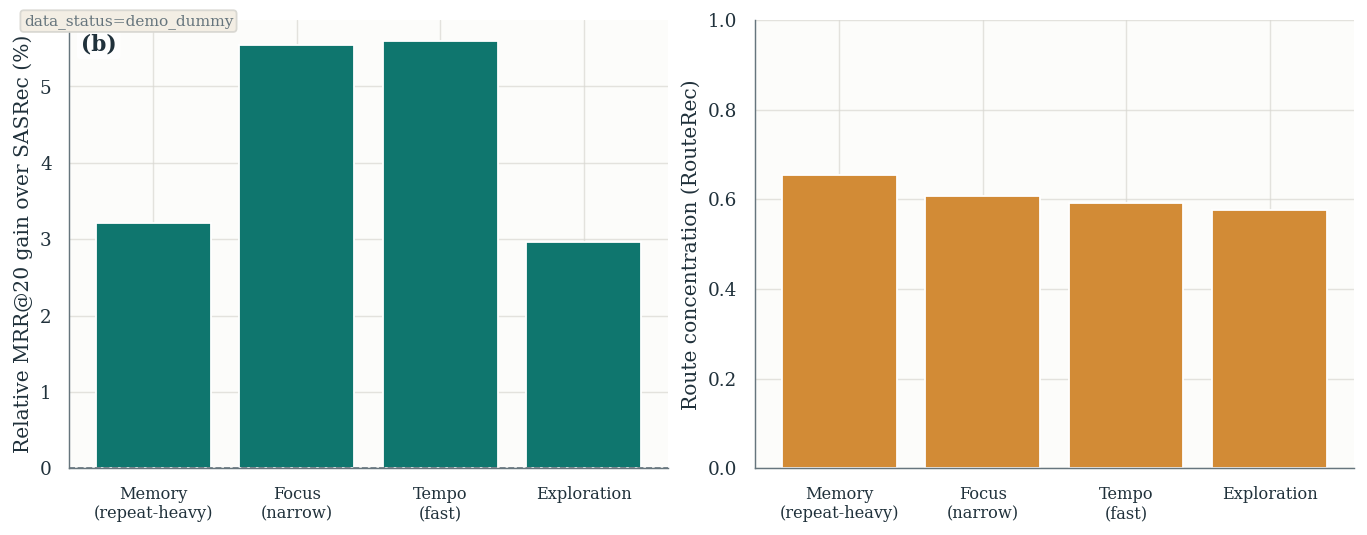

In [ ]:
# ── Figure I1(b) — Relative MRR@20 gain of RouteRec over SASRec by slice ─────────
sasrec_s = (
    slices_df[slices_df['model'] == 'SASRec']
    .groupby('group')['test_seen_mrr20'].mean()
    .reindex(SLICE_ORDER)
)
route_s = (
    slices_df[slices_df['model'] == 'RouteRec']
    .groupby('group')['test_seen_mrr20'].mean()
    .reindex(SLICE_ORDER)
)
gain_s = ((route_s - sasrec_s) / sasrec_s.clip(lower=1e-8)) * 100
cols_s = [PALETTE['route'] if g >= 0 else PALETTE['rose'] for g in gain_s.values]

fig, ax = plt.subplots(figsize=(6.0, 3.8), constrained_layout=True)
ax.bar([SLICE_LABELS[s] for s in SLICE_ORDER], gain_s.values, color=cols_s,
       edgecolor='white', linewidth=0.8)
ax.axhline(0, color=PALETTE['muted'], linewidth=0.9, linestyle='--')
ax.set_ylabel('Relative MRR@20 gain over SASRec (%)')
ax.tick_params(axis='x', labelsize=10)
clean_axes(ax)
annotate_demo(fig, slices_df)
plt.show()
